# 04 — Visualizações Finais & Dashboard
**Responsável**: P2 (Presencial)

**Objetivo**: Gráficos finais para apresentação, combinando resultados do modelo supervisionado e clustering.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar resultados
df_feat = pd.read_parquet('../data/processed/artist_country_features.parquet')
df_scores = pd.read_csv('../data/processed/model_results.csv')
df_clusters = pd.read_csv('../data/processed/cluster_labels.csv')

# Merge
df = df_feat.merge(df_scores[['artist_uri','country','recommend_score','recommend_label']],
    on=['artist_uri','country'], how='left')
df = df.merge(df_clusters[['artist_uri','country','cluster','profile']],
    on=['artist_uri','country'], how='left')
print(f'Shape: {df.shape}')

Shape: (13220, 23)


## 1. Ranking Final por País — Top 20 Recomendações

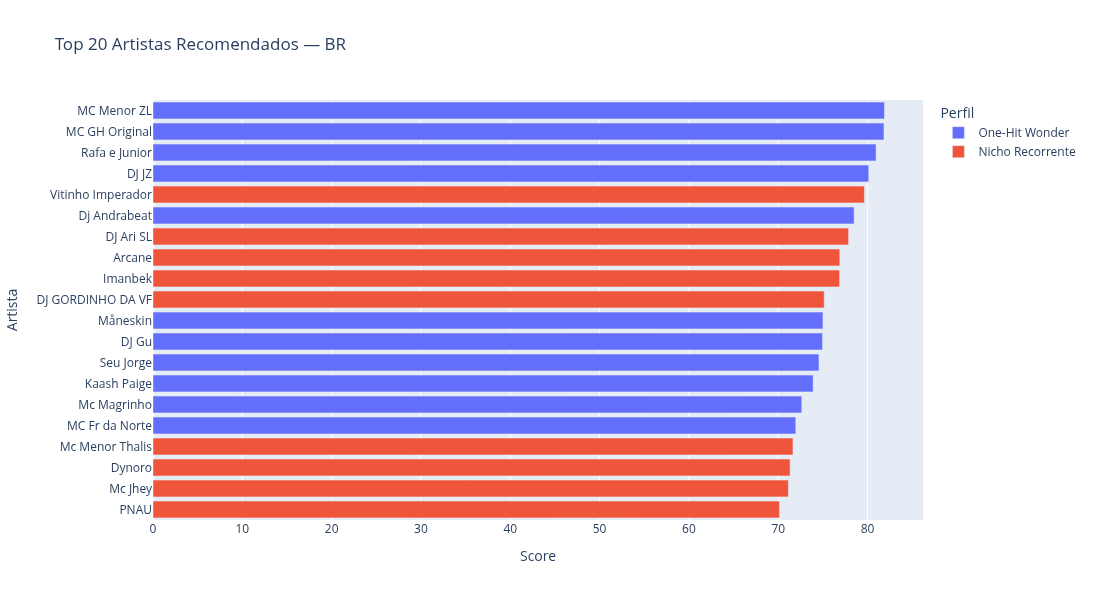

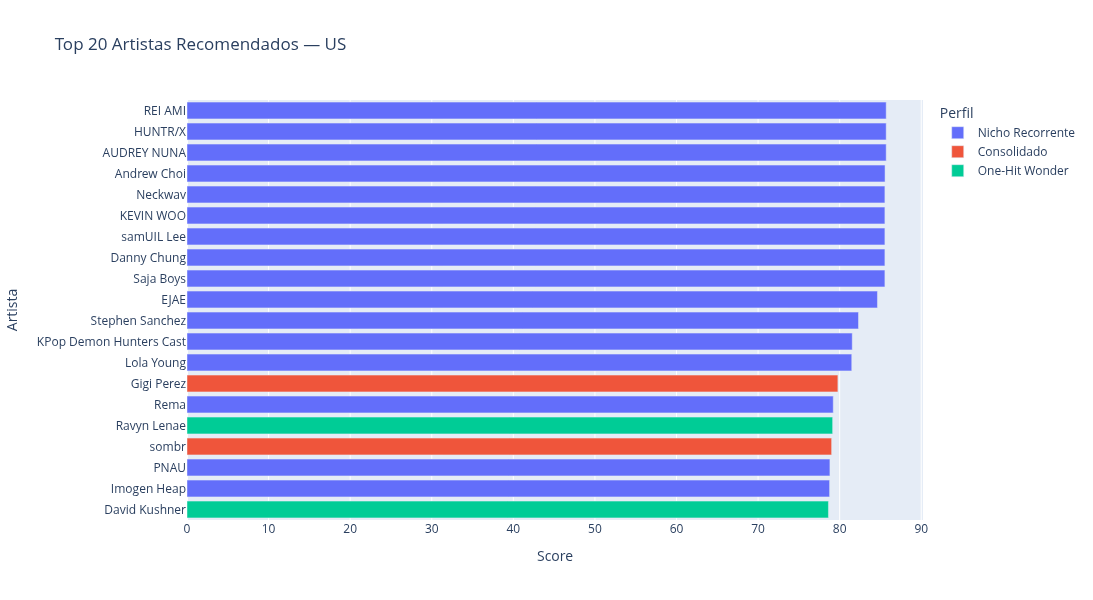

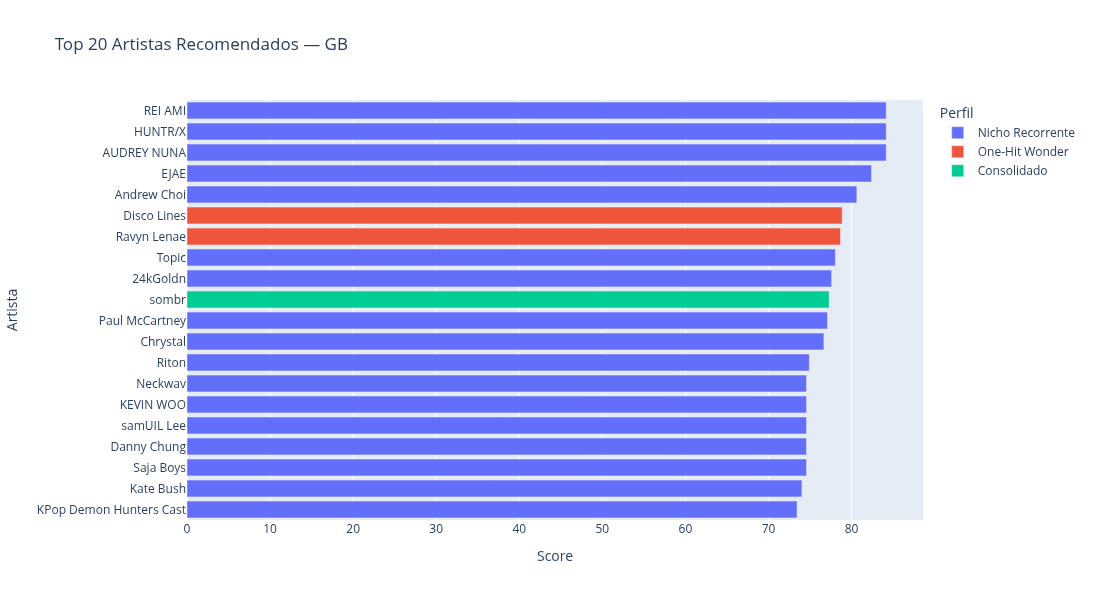

In [2]:
for country in ['br', 'us', 'gb']:
    top = df[df['country']==country].nlargest(20, 'recommend_score')
    fig = px.bar(top, x='recommend_score', y='artist_name',
        orientation='h', color='profile',
        title=f'Top 20 Artistas Recomendados — {country.upper()}',
        labels={'recommend_score':'Score','artist_name':'Artista','profile':'Perfil'})
    fig.update_layout(yaxis={'categoryorder':'total ascending'}, height=600)
    fig.show()

## 2. Scatter: Score vs Streams, colorido por Perfil

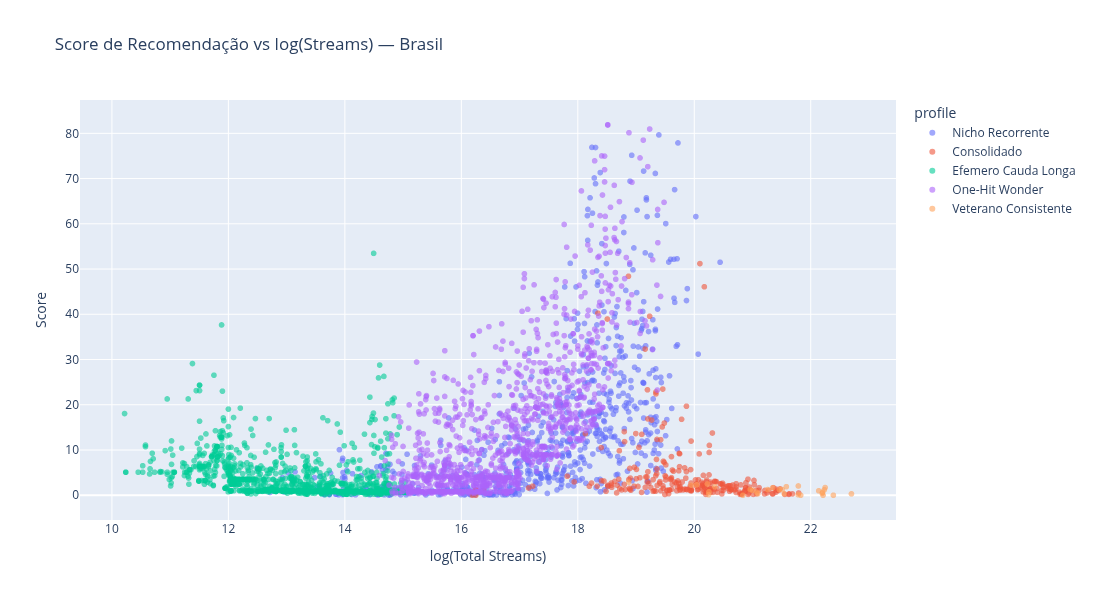

In [3]:
df_br = df[df['country']=='br'].dropna(subset=['recommend_score','profile']).copy()
df_br['log_streams'] = np.log1p(df_br['total_streams'])

fig = px.scatter(df_br, x='log_streams', y='recommend_score',
    color='profile', hover_data=['artist_name','total_tracks','avg_rank'],
    title='Score de Recomendação vs log(Streams) — Brasil',
    labels={'log_streams':'log(Total Streams)','recommend_score':'Score'},
    opacity=0.6)
fig.update_layout(height=600)
fig.show()

## 3. Heatmap: Presença de Artista por País

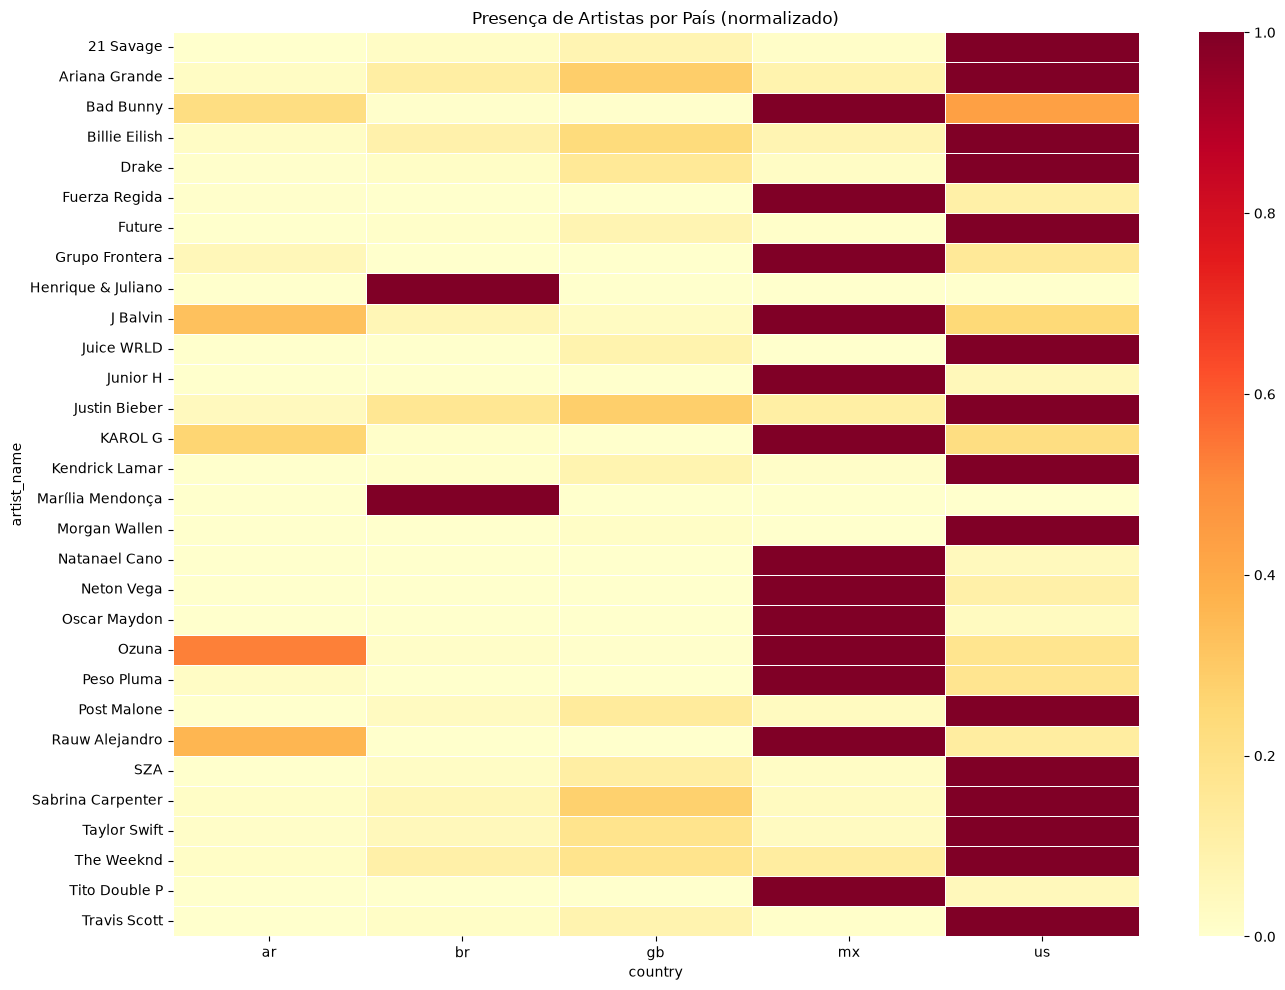

In [4]:
# Top 30 artistas globais
top_global = df.groupby('artist_name')['total_streams'].sum().nlargest(30).index
matrix = df[df['artist_name'].isin(top_global)].pivot_table(
    index='artist_name', columns='country', values='total_streams', aggfunc='sum').fillna(0)
matrix_norm = matrix.div(matrix.max(axis=1), axis=0)  # normalizar por artista

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(matrix_norm, cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Presença de Artistas por País (normalizado)')
plt.tight_layout()
plt.savefig('../docs/heatmap_artist_country.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Distribuição de Perfis por País

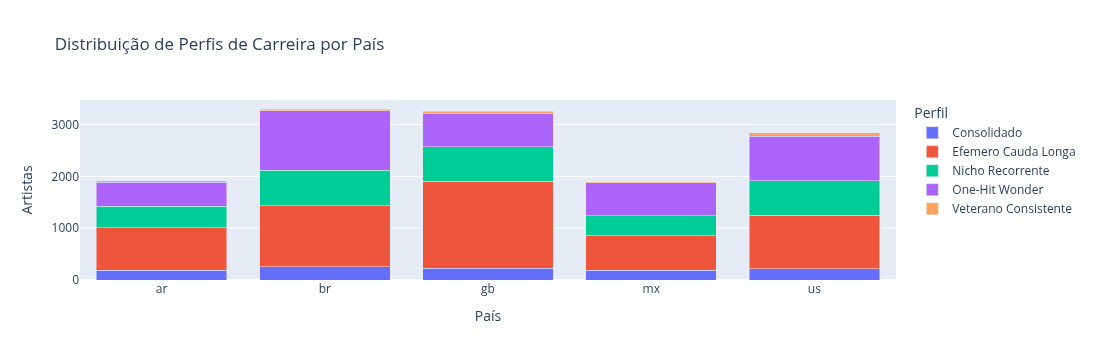

In [5]:
profile_counts = df.groupby(['country','profile']).size().reset_index(name='count')
fig = px.bar(profile_counts, x='country', y='count', color='profile',
    title='Distribuição de Perfis de Carreira por País',
    barmode='stack', labels={'count':'Artistas','country':'País','profile':'Perfil'})
fig.show()

## 5. Resultado Final — Tabela Interativa

In [8]:
# Tabela final para o produtor de eventos
country_input = 'br'  # ALTERAR para o país desejado
n_top = 50

final = df[df['country']==country_input].nlargest(n_top, 'recommend_score')[
    ['artist_name','recommend_score','profile','total_tracks','total_streams',
     'avg_rank','best_rank','stream_concentration','listener_ratio','trend_30d']
].reset_index(drop=True)
final.index += 1
final.columns = ['Artista','Score','Perfil','Tracks','Streams Total',
    'Rank Médio','Melhor Rank','Concentração','Ratio Ouvintes','Trend 30d']
final

,Artista,Score,Perfil,Tracks,Streams Total,Rank Médio,Melhor Rank,Concentração,Ratio Ouvintes,Trend 30d
1,MC Menor ZL,81.893811,One-Hit Wonder,2,109810701.0,47.303419,11,0.838888,0.440456,-0.198623
2,MC GH Original,81.835031,One-Hit Wonder,2,109810701.0,47.303419,11,0.838888,0.511059,-0.198623
3,Rafa e Junior,80.948472,One-Hit Wonder,4,225517903.0,27.145889,3,0.991442,0.530232,0.345424
4,DJ JZ,80.130608,One-Hit Wonder,3,158102013.0,47.836000,1,0.984737,0.582528,1.000000
5,Vitinho Imperador,79.641883,Nicho Recorrente,5,264226346.0,36.064018,3,0.817263,0.513546,-0.135787
6,Dj Andrabeat,78.493197,One-Hit Wonder,1,202116851.0,13.209877,2,1.000000,0.570653,-0.238478
7,DJ Ari SL,77.872808,Nicho Recorrente,5,366758120.0,46.168437,1,0.609633,0.484653,0.345424
8,Arcane,76.890618,Nicho Recorrente,4,83652759.0,105.774648,16,0.348987,0.439126,NaN
9,Imanbek,76.864693,Nicho Recorrente,4,88997593.0,85.357873,8,0.455551,0.504119,NaN
10,DJ GORDINHO DA VF,75.143949,Nicho Recorrente,3,165729121.0,40.390728,1,0.555840,0.975848,-0.081868
